In [12]:
import pandas as pd
import numpy as np
# insert path to load_aggregate_statistics function
import sys
sys.path.append('/Users/wayne/Desktop/Cluster/ClusterHome/gitrepo/2024/OncoTRAIL/src/prompt')

from utils import generate_mixed_violin_plot

In [13]:
results_dir_parent = '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage3'
agg_df_train = pd.read_csv(f"{results_dir_parent}/aggregate_statistics_stage3.csv", header=0)
agg_df_train

,Target,AUC,n_samples,mean_proba,CI,n_few_shot_added_mean,LLM_name,temp,top_p,min_p,top_k,n_few_shot,target_type
0,target-hemoglobin-grade2plus,0.752728,600,0.577500,"[0.717, 0.791]",15.441667,Qwen2.5-14B-IQ4-XS,1.0,0.8,0.05,10.0,16,lab
1,target-hemoglobin-grade2plus,0.741639,600,0.576333,"[0.705, 0.780]",15.441667,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.01,10.0,16,lab
2,target-hemoglobin-grade2plus,0.744572,600,0.586000,"[0.707, 0.781]",15.441667,Qwen2.5-14B-IQ4-XS,1.5,0.9,0.10,100.0,16,lab
3,target-hemoglobin-grade2plus,0.724467,600,0.582833,"[0.690, 0.763]",15.441667,Qwen2.5-14B-IQ4-XS,1.5,0.9,0.01,40.0,16,lab
4,target-hemoglobin-grade2plus,0.750311,600,0.583333,"[0.714, 0.786]",15.441667,Qwen2.5-14B-IQ4-XS,0.5,0.8,0.10,40.0,16,lab
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2047,target-ED-visit,0.624244,600,0.619750,"[0.583, 0.666]",3.996667,Qwen2.5-14B-IQ4-XS,1.0,0.9,0.01,40.0,4,clinic
2048,target-ED-visit,0.615683,600,0.618583,"[0.571, 0.659]",3.996667,Qwen2.5-14B-IQ4-XS,1.5,1.0,0.05,100.0,4,clinic
2049,target-ED-visit,0.641767,600,0.613167,"[0.604, 0.683]",3.996667,Qwen2.5-14B-IQ4-XS,1.0,0.9,0.01,10.0,4,clinic
2050,target-ED-visit,0.661928,600,0.625417,"[0.622, 0.701]",3.996667,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.01,10.0,4,clinic


In [14]:
qwen_best_stage1 = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage1/qwen_best_results_stage1.csv', index_col=0) 
qwen_best_stage1['temp'] = 0.7
qwen_best_stage1['min_p'] = 0
qwen_best_stage1['top_p'] = 0.8
qwen_best_stage1['top_k'] = 20
qwen_best_stage1

,Target,AUC,n_samples,mean_proba,LLM_name,prompt_num,tabular,n_few_shot,temp,min_p,top_p,top_k
0,target-AKI-grade2plus,0.664702,600,0.438250,Qwen2.5-14B-IQ4-XS,17,note-tabular,4,0.7,0,0.8,20
1,target-ALT-grade2plus,0.668560,600,0.433833,Qwen2.5-14B-IQ4-XS,17,note-tabular,16,0.7,0,0.8,20
2,target-AST-grade2plus,0.699164,600,0.464500,Qwen2.5-14B-IQ4-XS,17,note-tabular,16,0.7,0,0.8,20
3,target-ED-visit,0.683006,600,0.384833,Qwen2.5-14B-IQ4-XS,40,note-tabular,4,0.7,0,0.8,20
4,target-bilirubin-grade2plus,0.807515,600,0.423750,Qwen2.5-14B-IQ4-XS,32,note-tabular,8,0.7,0,0.8,20
5,target-death-in-30d,0.816199,600,0.325500,Qwen2.5-14B-IQ4-XS,40,note-tabular,4,0.7,0,0.8,20
6,target-death-in-365d,0.797689,600,0.554667,Qwen2.5-14B-IQ4-XS,32,note-tabular,16,0.7,0,0.8,20
7,target-esas-anxiety-3pt-change,0.535734,600,0.570000,Qwen2.5-14B-IQ4-XS,8,note,8,0.7,0,0.8,20
8,target-esas-appetite-3pt-change,0.537249,600,0.552167,Qwen2.5-14B-IQ4-XS,17,note,8,0.7,0,0.8,20
9,target-esas-depression-3pt-change,0.577342,600,0.499583,Qwen2.5-14B-IQ4-XS,40,note,4,0.7,0,0.8,20


Significant: Mean difference between 0.5 and 1.5: 0.004
  Lab: Mean difference = 0.011
  Symptom: Mean difference = -0.005
  Clinic: Mean difference = 0.015


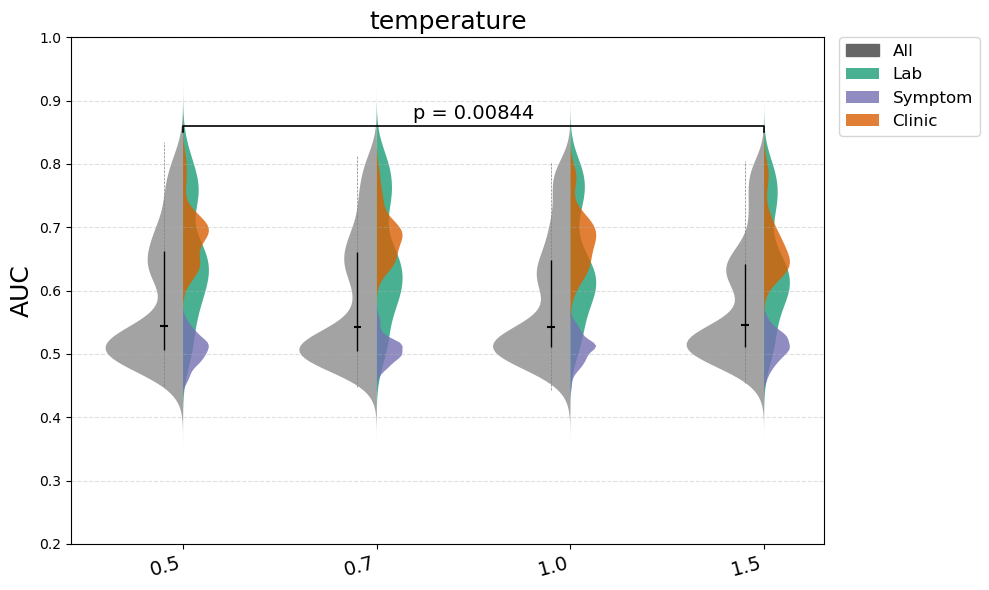

In [15]:
# fig=generate_mixed_violin_plot(agg_df_train, 'temp', 0, ["0.5", "0.7", "1.0", "1.5"], "Prediction performance by LLM temperature", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);
fig=generate_mixed_violin_plot(agg_df_train, 'temp', 0, ["0.5", "0.7", "1.0", "1.5"], "temperature", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);

Significant: Mean difference between 0.01 and 0.1: -0.002
  Lab: Mean difference = 0.001
  Symptom: Mean difference = -0.004
  Clinic: Mean difference = -0.005


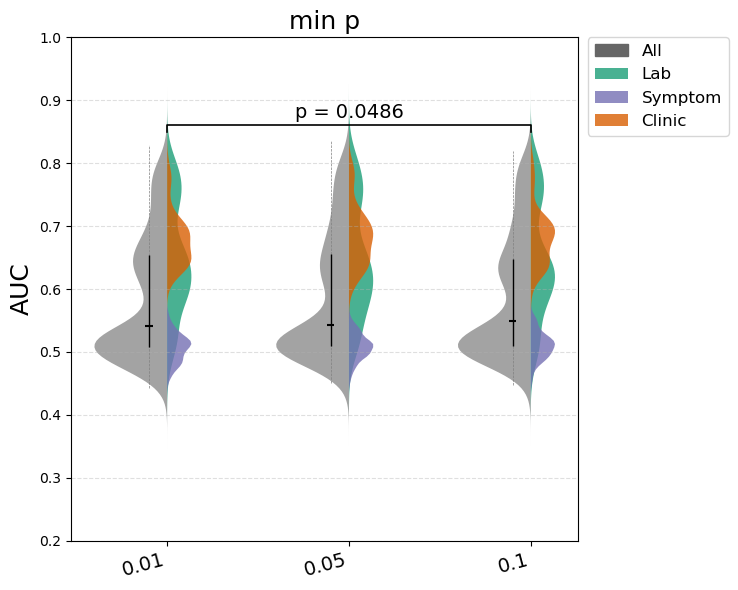

In [16]:
# fig=generate_mixed_violin_plot(agg_df_train, 'min_p', 0, None, "Prediction performance by min_p", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);
fig=generate_mixed_violin_plot(agg_df_train, 'min_p', 0, None, "min p", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);

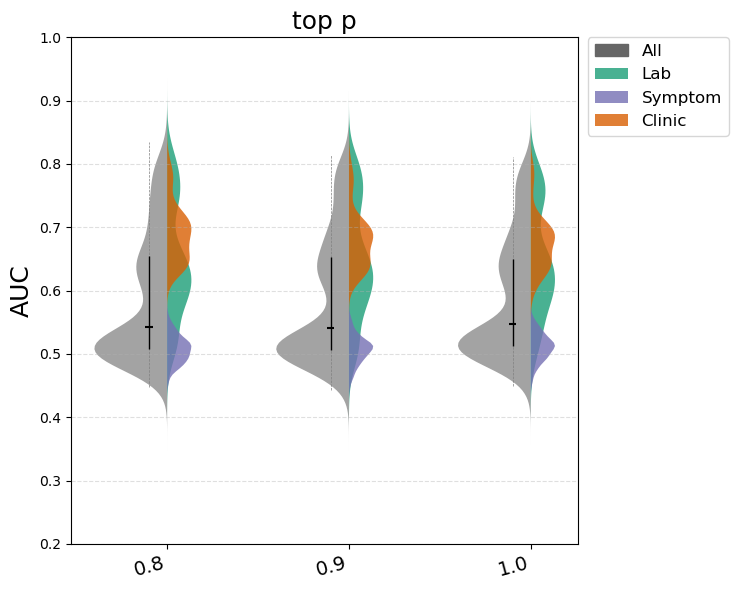

In [17]:
# fig=generate_mixed_violin_plot(agg_df_train, 'top_p', 0, None, "Prediction performance by top_p", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);
fig=generate_mixed_violin_plot(agg_df_train, 'top_p', 0, None, "top p", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);

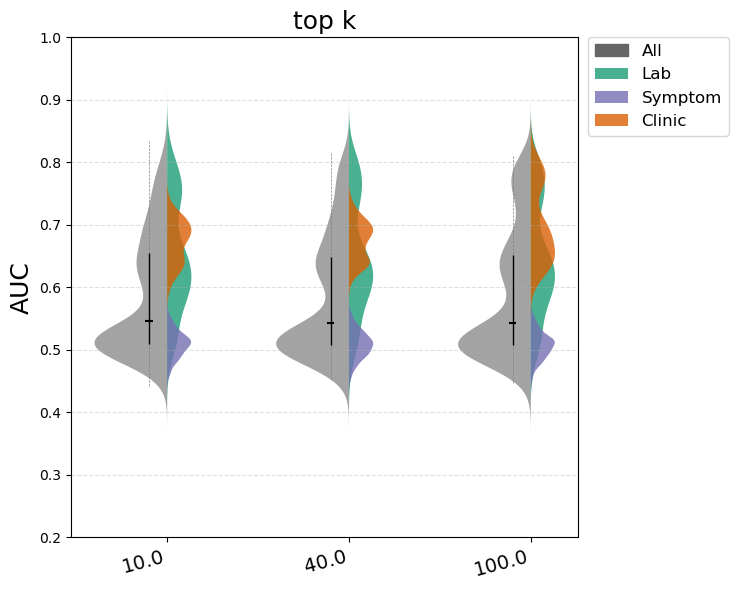

In [18]:
# fig=generate_mixed_violin_plot(agg_df_train, 'top_k', 0, None, "Prediction performance by top_k", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);
fig=generate_mixed_violin_plot(agg_df_train, 'top_k', 0, None, "top k", True, ['Target', 'LLM_name', 'temp', 'min_p', 'top_p', 'top_k', 'n_few_shot'], False);

In [11]:
# concatenate qwen_best_stage1 with aggregate_statistics_df
aggregate_statistics_df_w_stage1 = pd.concat([agg_df_train, qwen_best_stage1], ignore_index=True)

# choose the best model for each target
aggregate_statistics_df_w_stage1.sort_values(by='AUC', ascending=False, inplace=True)
overall_best_df = aggregate_statistics_df_w_stage1.groupby(['Target']).first().reset_index()
overall_best_df

,Target,AUC,n_samples,mean_proba,CI,n_few_shot_added_mean,LLM_name,temp,top_p,min_p,top_k,n_few_shot,target_type,prompt_num,tabular
0,target-AKI-grade2plus,0.694489,600,0.453917,"[0.624, 0.764]",3.995000,Qwen2.5-14B-IQ4-XS,0.7,0.9,0.05,10.0,4,lab,17.0,note-tabular
1,target-ALT-grade2plus,0.668560,600,0.433833,"[0.611, 0.711]",15.696667,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.00,20.0,16,lab,17.0,note-tabular
2,target-AST-grade2plus,0.710451,600,0.468167,"[0.646, 0.769]",15.098333,Qwen2.5-14B-IQ4-XS,0.5,0.9,0.10,10.0,16,lab,17.0,note-tabular
3,target-ED-visit,0.683006,600,0.384833,"[0.632, 0.709]",3.996667,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.00,20.0,4,clinic,40.0,note-tabular
4,target-bilirubin-grade2plus,0.834718,600,0.423583,"[0.783, 0.879]",7.988333,Qwen2.5-14B-IQ4-XS,0.5,0.8,0.05,10.0,8,lab,32.0,note-tabular
5,target-death-in-30d,0.816199,600,0.325500,"[0.753, 0.855]",3.996667,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.00,20.0,4,clinic,40.0,note-tabular
6,target-death-in-365d,0.797689,600,0.554667,"[0.677, 0.758]",15.598333,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.00,20.0,16,clinic,32.0,note-tabular
7,target-esas-anxiety-3pt-change,0.560311,600,0.647833,"[0.512, 0.610]",7.988333,Qwen2.5-14B-IQ4-XS,1.5,0.9,0.05,40.0,8,symptom,8.0,note
8,target-esas-appetite-3pt-change,0.545112,600,0.569583,"[0.500, 0.587]",7.990000,Qwen2.5-14B-IQ4-XS,0.5,1.0,0.01,40.0,8,symptom,17.0,note
9,target-esas-depression-3pt-change,0.577342,600,0.499583,"[0.517, 0.625]",3.995000,Qwen2.5-14B-IQ4-XS,0.7,0.8,0.00,20.0,4,symptom,40.0,note


In [ ]:
# save results
results_dir = "/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage3"
# for rows in overall_best_df for which 'temp' = 0.7, 'min_p' = 0, 'top_p' = 0.8, 'top_k' = 20, change all these values to -1
best_results_to_save = overall_best_df.copy()
for index, row in best_results_to_save.iterrows():
    if row['temp'] == 0.7 and row['min_p'] == 0 and row['top_p'] == 0.8 and row['top_k'] == 20:
        best_results_to_save.loc[index, 'temp'] = -1
        best_results_to_save.loc[index, 'min_p'] = -1
        best_results_to_save.loc[index, 'top_p'] = -1
        best_results_to_save.loc[index, 'top_k'] = -1
best_results_to_save.drop(columns=['CI']).to_csv(f"{results_dir}/llmhyperparameters_best_results_stage3.csv")
best_results_to_save.to_csv(f"{results_dir}/llmhyperparameters_best_results_stage3_withCI.csv")